In [ ]:
import math
import ast
import pandas as pd
import numpy as np
import ipynbname
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from Testing.DRTLO_QN_R1 import *
from Functions.AutoCloud_V2 import *
from Functions.DataCloud_V2 import *
from Functions.Utils import *
#from Functions.Utils_RTLO import *
from Functions.Graphs import *
from Functions.TedaGraphs import *
import optuna
from optuna.samplers import RandomSampler
from optuna.exceptions import TrialPruned

FileName = ipynbname.name()
study_dir = f'Optimization/{FileName}/'
out_path = f'Optimization/{FileName}/Optimization.csv'
study_dir = os.path.normpath(study_dir)
out_path = os.path.normpath(out_path)

os.makedirs(study_dir, exist_ok=True)

RS = pd.read_excel(r'Dataset\RS.xlsx')
#RS = exponential_moving_average_df(RS,0.25)
HI = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = HI['PC1'].values

def to_nearest_pow10(val):
    return 10 ** np.round(np.log10(val))

def SelSampler(mode='auto'):
    '''mode: auto, random,  tpe'''
    if mode == 'auto':
        sampler = None
    elif mode == 'tpe':
        sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=250)
    elif mode == 'random':
        sampler=RandomSampler()
    return sampler

In [ ]:
params =  {'nI': 3, 'nR': 3, 'nO': 3, 'N1': 0.1,
            'τ': 23, 'mode': 1, 'act': 0}

nI,nR,nO,N1,τ,mode,act= list(params.values())
X, Y, Z = PrepareData(RS, HI, nX=nI, nY=nO, mY=0, nZ=1, mode='past')

teda=AutoCloud(m=2.5,nI=nI,nR=[nR],nO=nO,ηS=[N1],mode=mode,
               tau=τ,rho=0.01,eol=0.3,ref=len(sig)-nI,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])

teda.RUL_Granularity()
print(teda.wape_HI,teda.wape_RUL)
PlotDSI_3D_PLT(teda)
teda.c = np.append(teda.c,teda.gm)   
#PlotGranulesSpace(teda,w=700,h=700)

In [ ]:
print(xxx)

In [ ]:
df2 = []
nMax = 20
names = ['MAPE', 'm', 'nI', 'nR', 'nO', 'mO', 'N1','TAU','past/ahead','activation']
for i in range(1):
    print('iteration:',i+1)
    def objective(trial):
        m = trial.suggest_float('m', 1.75, 4.25,step=0.25)
        nI = trial.suggest_int('nI', 2, nMax) 
        n_layers = trial.suggest_int('n_layers', 2, 2)
        nR = [trial.suggest_int(f'nR_layer_{l}', 1, 64) for l in range(n_layers)]
        nO = trial.suggest_int('nO', 1, nMax) 
        mO = trial.suggest_int('mO', 0, nMax) 
        N1 = trial.suggest_float('N1', 1e-9, 1e-1,log=True)
        τ = trial.suggest_float('τ', 1, 50,log=True)
        mode = trial.suggest_int('mode', 1,1)  
        act = trial.suggest_int('act',0,1)  

        if mode == 'past':
            if nO > nI: raise TrialPruned()
        elif mode == 'ahead':
            if nI> nMax or nO> nMax: raise TrialPruned()
            elif mO > nI: raise TrialPruned()
            
        X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
        nI = len(Y[0])
            
        teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1],mode=mode,act=act,
                    tau=τ,rho=0.0,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
        for j,_ in enumerate(X[:]):
            teda.run(X[j])
            teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1)
            teda.Adapt(Y[j],Z[j])

            if j%25 == 0:
                trial.report(teda.wape_RUL+teda.wape_HI, j)
            '''if j == 50:
                if teda.wape_RUL > 0.35: raise TrialPruned()
                if teda.wape_HI  > 0.35: raise TrialPruned()

            if j%35 == 0 and len(teda.wape_HI_hist==j):
                if np.sum(teda.wape_HI_hist[:j])/j > 0.4: raise TrialPruned()
            if len(teda.wape_RUL_hist==j):
                if np.sum(teda.wape_RUL_hist[:j])/j > 0.4: raise TrialPruned()'''

            if trial.should_prune():
                raise optuna.TrialPruned()
            
        return teda.wape_RUL+ teda.wape_HI

    pruner=optuna.pruners.HyperbandPruner()
    study = optuna.create_study(
        direction='minimize',pruner=pruner,
        sampler=SelSampler(mode='tpe'))

    study.optimize(objective, n_trials=5000, timeout=900)
    trials = study.best_trials
    trials_errors = [list(trial.values) for trial in trials]
    trials_params = [list(trial.params.values()) for trial in trials]

    for trial in study.best_trials:
        p = trial.params
        nR_list = [p[f'nR_layer_{l}'] for l in range(p['n_layers'])]
        
        row = [trial.values[0],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['τ'],p['mode'],p['act']]
        df2.append(row)

df2 = pd.DataFrame(df2, columns=names)

if os.path.isfile(out_path) and out_path.startswith(study_dir):
    df1 = pd.read_csv(out_path)
    df_stdy = pd.concat([df1, df2], ignore_index=True)

else: df_stdy = df2

df_stdy.to_csv(out_path, index=False)
opt_path = os.path.join(study_dir,f'opt_{len(os.listdir(study_dir))-1}.csv')
df2.to_csv(opt_path, index=False)

In [97]:
df_params = pd.read_csv(out_path)
#df_params = pd.read_csv(opt_path)
df_params = df_params[(df_params['MAPE'] <= 0.25)]
params_list = df_params.values[:,1:]
df_params

,MAPE,m,nI,nR,nO,mO,N1,TAU,past/ahead,activation
4,0.206592,3.10,19,[60],12,19,2.406348e-03,1.069486,1,0
5,0.193976,2.60,6,[20],19,0,6.883579e-02,3.405540,1,0
7,0.243285,2.00,17,[62],17,12,1.628638e-02,1.037362,1,0
8,0.200606,3.50,2,"[54, 8]",9,4,1.849244e-07,2.000551,1,0
9,0.205075,3.10,6,"[22, 63]",19,13,1.580692e-05,10.915589,1,0
12,0.216299,3.30,11,[7],11,2,4.502262e-07,5.470613,1,0
15,0.220510,3.75,15,"[35, 20]",4,8,1.958558e-02,7.883716,1,0
17,0.220074,3.50,19,[55],2,3,1.664480e-06,20.664133,1,1
18,0.223420,3.00,11,"[59, 33, 33]",14,16,3.771709e-09,2.293694,1,0
23,0.188298,2.00,16,[55],5,8,4.396568e-09,5.586132,1,0


0.17720402164045804 0.020124830746902023


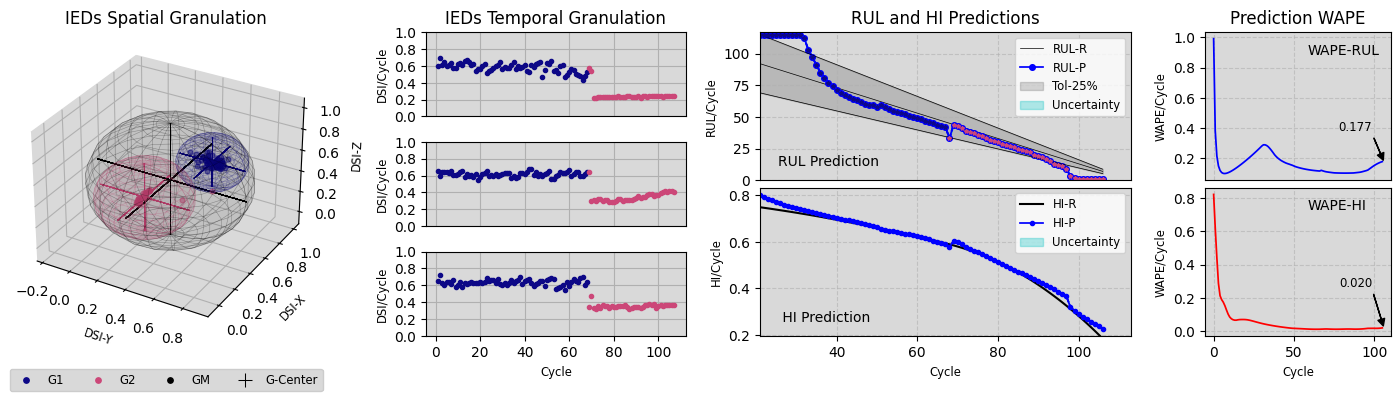

In [94]:
params_list = df_params.values[:,1:]

for i,params in enumerate(params_list):
    m,nI,nR,nO,mO,N1,τ,mode,act = params
    X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
    nI=len(Y[0])
    if isinstance(nR, str): nR = ast.literal_eval(nR)

    teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1],mode=mode,act=act,
                tau=τ,rho=0.03,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
    for j,_ in enumerate(X[:]):
        teda.run(X[j])
        teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1,show=False)
        teda.Adapt(Y[j],Z[j])
    print(teda.wape_RUL,teda.wape_HI)

    teda.c = np.append(teda.c,teda.gm)  
    #PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])
    PlotDSI_3D_PLT(teda)

In [ ]:
mode

In [ ]:
m,nI,nR,nO,mO,N1,τ,mode,act = params_list[0]
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
nI=len(Y[0])
if isinstance(nR, str): nR = ast.literal_eval(nR)

teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1],mode=mode,act=act,
            tau=τ,rho=0.03,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])
print(teda.wape_RUL,teda.wape_HI)

teda.c = np.append(teda.c,teda.gm)  
#PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])
#PlotDSI_3D_PLT(teda)

print((teda.wape_RUL_hist[35]))
print(np.sum(teda.wape_RUL_hist[:35])/35, np.mean(teda.wape_RUL_hist))
print((teda.wape_HI_hist[35]))
print(np.sum(teda.wape_HI_hist[:35])/35, np.mean(teda.wape_HI_hist))